# 06 事前蒙地卡羅壓力測試

對每季、每個策略，以決策日前一年的組合日報酬估計平均與標準差，假設 i.i.d. 常態，模擬 100,000 條持有期路徑，計算 95% VaR 與 CVaR，再與實際實現的季報酬比較。

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

In [2]:
st = pd.read_csv(SUMMARY / "stress.csv")
st.pivot_table(index="strategy", columns="quarter", values="CVaR").round(4)

quarter,2025_03,2025_06,2025_09,2025_12,2026_03
strategy,,,,,
EqualWeight,-0.1197,-0.1963,-0.1587,-0.1274,-0.1053
MVO-cap10|LW-ConstCorr|GMVP,-0.0680,-0.1269,-0.1118,-0.1092,-0.1106
MVO-cap10|LW-ConstCorr|MSRP,-0.1224,-0.1619,-0.1549,-0.1325,-0.0773
MVO-round-P100|LW-ConstCorr|GMVP,-0.0603,-0.0917,-0.0865,-0.0869,-0.0880
MVO-round-P100|LW-ConstCorr|MSRP,-0.1396,-0.1942,-0.1778,-0.1417,-0.0870
MVO-round-P20|LW-ConstCorr|GMVP,-0.0598,-0.0917,-0.0863,-0.0876,-0.0889
MVO-round-P20|LW-ConstCorr|MSRP,-0.1362,-0.1988,-0.1776,-0.1524,-0.0853
MVO|LW-ConstCorr|GMVP,-0.0606,-0.0919,-0.0866,-0.0867,-0.0882
MVO|LW-ConstCorr|MSRP,-0.1382,-0.1937,-0.1765,-0.1423,-0.0866


## VaR 穿越次數（實現報酬 < 事前 95% VaR）

In [3]:
br = st.groupby("strategy").agg(breaches=("Breach", "sum"), quarters=("Breach", "size"),
                                 mean_VaR=("VaR", "mean"), mean_realized=("Realized", "mean"))
br.sort_values("breaches", ascending=False)

,breaches,quarters,mean_VaR,mean_realized
strategy,,,,
EqualWeight,0,5,-0.1035,0.1332
MVO-cap10|LW-ConstCorr|GMVP,0,5,-0.0817,0.0067
MVO-cap10|LW-ConstCorr|MSRP,0,5,-0.0966,0.0602
MVO-round-P100|LW-ConstCorr|GMVP,0,5,-0.0634,0.0138
MVO-round-P100|LW-ConstCorr|MSRP,0,5,-0.1104,0.0574
MVO-round-P20|LW-ConstCorr|GMVP,0,5,-0.0635,0.0110
MVO-round-P20|LW-ConstCorr|MSRP,0,5,-0.1127,0.0548
MVO|LW-ConstCorr|GMVP,0,5,-0.0635,0.0131
MVO|LW-ConstCorr|MSRP,0,5,-0.1099,0.0575


Text(0.5, 1.0, 'Ex-ante 95% VaR vs realised quarterly return')

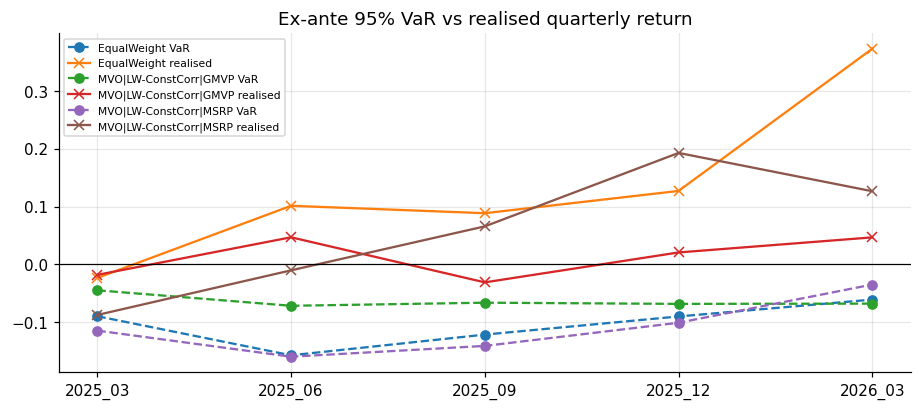

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for s, g in st[st["strategy"].str.contains("MVO\\|") | (st["strategy"] == "EqualWeight")].groupby("strategy"):
    ax.plot(g["quarter"], g["VaR"], marker="o", ls="--", label=f"{s} VaR")
    ax.plot(g["quarter"], g["Realized"], marker="x", label=f"{s} realised")
ax.axhline(0, color="k", lw=0.8); ax.legend(fontsize=7); ax.set_title("Ex-ante 95% VaR vs realised quarterly return")

**解讀**：5 季中沒有任何策略的實現報酬跌破事前 95% VaR。研究期間是單邊多頭，事前以前一年波動估計的尾端風險（含 2025 年 4 月關稅衝擊前後）相對保守。這也意味著本研究的樣本外期間沒有經歷真正的下跌壓力，GMVP 類防禦型組合的價值在此期間無從體現。